# Fase 3 — Primer XGBoost para kt(t+1) (nodo 1736)

Modelo que predice `kt(t+1)` y debe **superar a smart persistence (skill > 0)**.
Se reconstruye GHI como `kt_pred * clearsky_ghi(τ)` y se evalúa sobre las MISMAS
horas operativas que persistence A (comparación justa).

**Anti-leakage** (ver `forecasting/features.py`): la fila se indexa por la hora
objetivo τ. Solo entran deterministas known-future en τ (`clearsky_*`, zenith,
calendario cíclico), estáticas del nodo (lat/lon/msnm) y observadas **rezagadas**
(kt, meteo, aerosoles, nubes a τ-1..). Se excluyen ghi/dni/dhi crudos en τ y las UV.

**Portabilidad:** el device se autodetecta (`cuda` en la máquina Ubuntu, `cpu` en
la Mac). Forzar con la variable de entorno `RS_DEVICE`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecasting import config as C
from forecasting.data.loaders import cargar_serie_nodo
from forecasting import features as F
from forecasting.models import xgb as MX
from forecasting.eval import persistence as P, comparar as CMP
from forecasting.viz import VisualizadorForecast

df = cargar_serie_nodo(1736)
feat = F.construir_features(df)
print('device:', MX.detectar_device(), '| n_features:', len(F.columnas_features(feat)))

device: cuda | n_features: 35


## Entrenamiento (train 2020-22, early stopping en val 2023)

In [2]:
model, cols, splits = MX.entrenar(feat)
print('best_iteration:', model.best_iteration)

ruta_modelo = os.path.join(C.DIR_MODELOS, 'xgb_t1_nodo1736.json')
model.save_model(ruta_modelo)
print('modelo guardado:', ruta_modelo)

best_iteration: 226
modelo guardado: /home/team-e/Documentos/DSI/Proyecto_Radiacion_Solar/Results/Tamaulipas/forecast/modelos/xgb_t1_nodo1736.json


## Evaluación vs persistence (val y test), con R², global + segmentado por fill_flag

In [3]:
per = P.smart_persistence(df)
anios = {'val': C.ANIOS_VAL, 'test': C.ANIOS_TEST}
tablas = []
for nombre in ['val', 'test']:
    pred = MX.predecir_ghi(model, splits[nombre], cols)
    ref = per.loc[per.index.year.isin(anios[nombre]), 'ghi_pred_A']
    t = CMP.comparar(pred, ref, nombre='xgb').assign(split=nombre)
    tablas.append(t)
tab = pd.concat(tablas, ignore_index=True)
tab.to_csv(os.path.join(C.DIR_RESULTADOS, 'fase3_xgb_metrics.csv'), index=False)
tab.round(3)

/home/team-e/miniconda3/envs/rs/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [17:03:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,segmento,n,RMSE_persistence,RMSE_xgb,MAE_xgb,MBE_xgb,R2_persistence,R2_xgb,skill,split
0,global,4112,84.625,77.271,42.054,3.144,0.921,0.935,0.087,val
1,limpio_ff0,3712,86.679,79.030,42.737,2.342,0.912,0.927,0.088,val
2,rellenado_ff_pos,400,62.425,58.471,35.714,10.593,0.890,0.903,0.063,val
3,global,4123,84.873,79.783,46.515,1.375,0.916,0.926,0.060,test
4,limpio_ff0,3734,86.482,81.511,47.810,1.477,0.906,0.917,0.057,test
5,rellenado_ff_pos,389,67.497,60.747,34.087,0.396,0.887,0.908,0.100,test


## Importancia de features (gain)

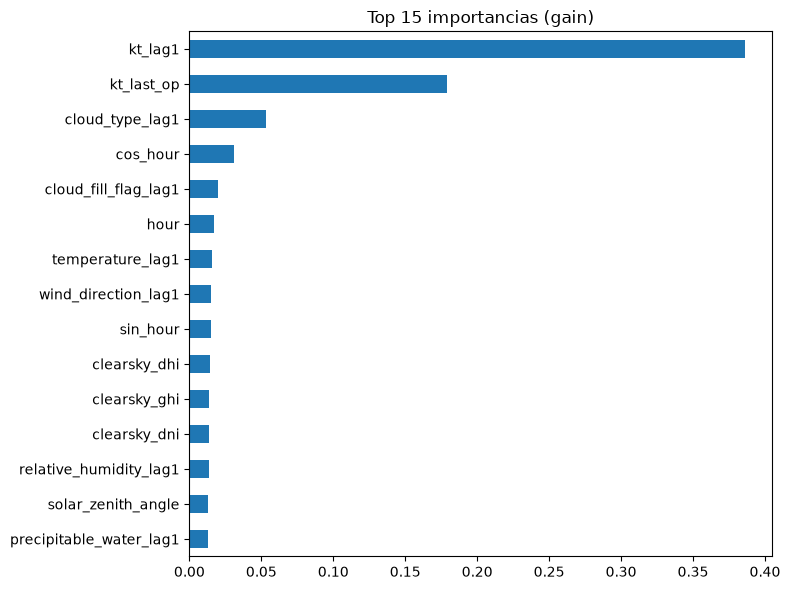

In [4]:
imp = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15)[::-1].plot.barh(ax=ax)
ax.set_title('Top 15 importancias (gain)'); plt.tight_layout(); plt.show()

## Visualización temporal: observado vs XGBoost vs persistence (test 2024)

`VisualizadorForecast` alinea las tres curvas en hora local (UTC-6) y permite
filtrar por **año, mes, día concreto o rango de fechas**. Solo horas operativas.

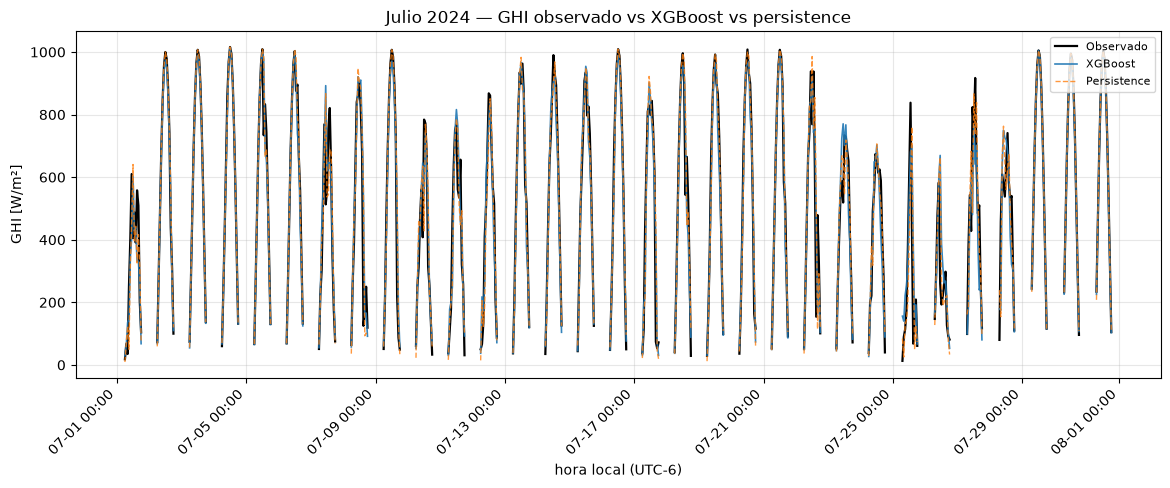

,modelo,n,RMSE,MAE,MBE,R2,skill_vs_persist
0,XGBoost,396,92.750,56.638,-5.151,0.910,0.059
1,Persistence,396,98.557,56.353,0.523,0.898,NaN


In [5]:
pred_test = MX.predecir_ghi(model, splits['test'], cols)
ref_test = per.loc[per.index.year == 2024, ['kt_pred_A', 'ghi_pred_A']]
viz = VisualizadorForecast.desde_predicciones(pred_test, per)

# Un mes completo.
viz.serie_temporal(mes=7, variable='ghi')
plt.title('Julio 2024 — GHI observado vs XGBoost vs persistence'); plt.show()

# Métricas de esa ventana.
viz.metricas(mes=7).round(3)

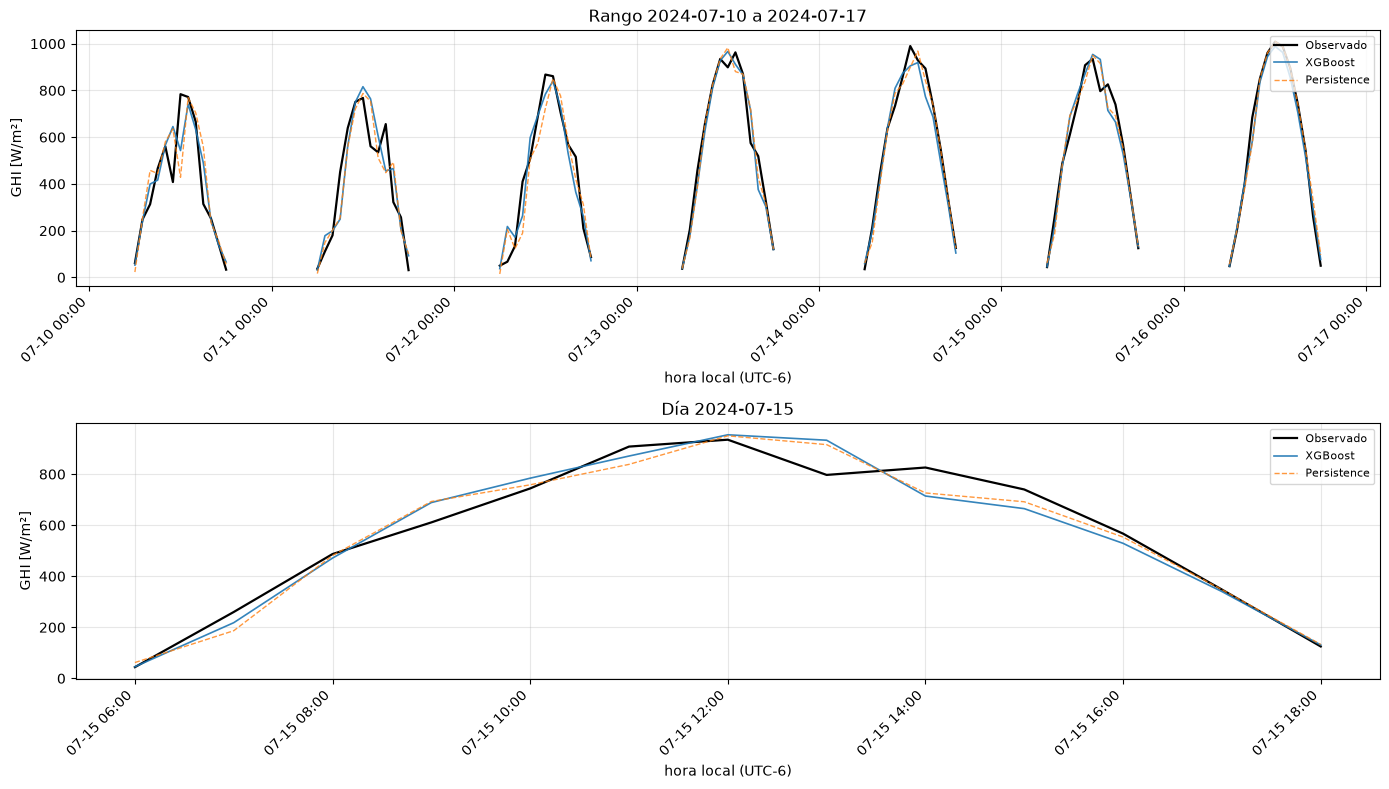

In [6]:
# Un rango de fechas y un día concreto (elige aquí lo que quieras inspeccionar).
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
viz.serie_temporal(inicio='2024-07-10', fin='2024-07-17', variable='ghi', ax=ax[0])
ax[0].set_title('Rango 2024-07-10 a 2024-07-17')
viz.serie_temporal(dia='2024-07-15', variable='ghi', ax=ax[1])
ax[1].set_title('Día 2024-07-15')
plt.tight_layout(); plt.show()

## Dispersión predicho vs observado (XGB y persistence), con R²

Coloreado por `fill_flag` (relleno satelital). Admite los mismos filtros.

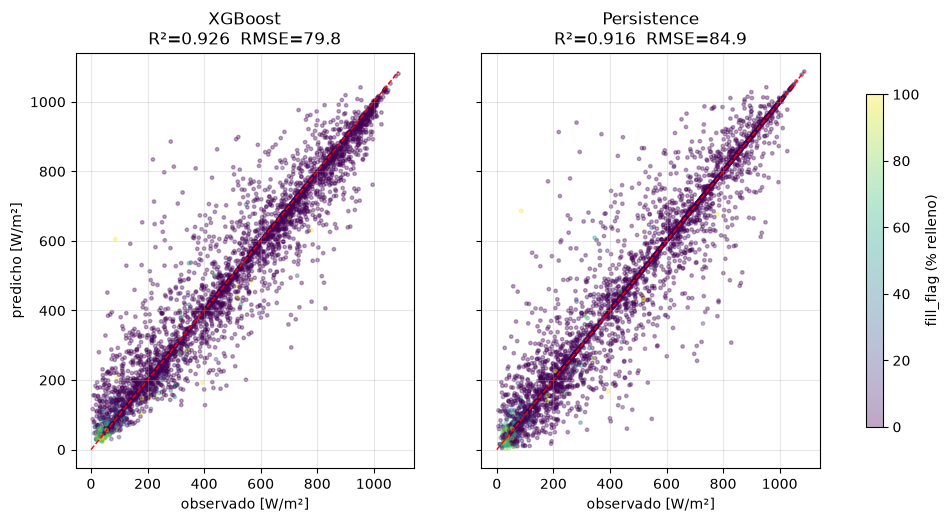

In [7]:
# Todo el test 2024.
viz.dispersion(variable='ghi', color_fill=True)
plt.show()

## Días más difíciles

Días donde se espera que el modelo sufra: **nublados** (kt medio bajo), **variables**
(alta desviación intradía de kt) y/o con **poca información real** (alta fracción de
relleno satelital, `fill_flag>0`). Criterios: `nublado`, `variabilidad`, `relleno`,
`combinado` (default, normaliza y suma nubosidad + variabilidad + relleno) y
`error_xgb` (el RMSE real del modelo, para validar la intuición).

In [8]:
print('Días más NUBLADOS (kt medio más bajo):')
display(viz.dias_dificiles(n=10, criterio='nublado'))
print('\nTop días difíciles (combinado = nubosidad + variabilidad + relleno):')
display(viz.dias_dificiles(n=10, criterio='combinado'))
print('\nTop días por error real del modelo (error_xgb):')
display(viz.dias_dificiles(n=10, criterio='error_xgb'))

Días más NUBLADOS (kt medio más bajo):


,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad
dia_local,,,,,,,
2024-06-23,13,0.150,0.140,0.154,119.716,43.918,0.850
2024-02-17,10,0.174,0.096,0.100,55.123,29.522,0.826
2024-06-30,13,0.181,0.141,0.231,91.333,67.981,0.819
2024-06-22,13,0.190,0.094,0.154,80.060,61.612,0.810
2024-01-07,10,0.208,0.078,0.100,28.724,48.365,0.792
2024-02-16,10,0.226,0.090,0.000,73.131,83.443,0.774
2024-12-21,9,0.231,0.149,0.111,60.279,57.386,0.769
2024-04-22,12,0.232,0.144,0.083,73.683,53.374,0.768
2024-03-18,11,0.255,0.113,0.091,135.677,119.410,0.745



Top días difíciles (combinado = nubosidad + variabilidad + relleno):


,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad,score
dia_local,,,,,,,,
2024-12-06,9,0.487,0.302,0.556,110.379,129.550,0.513,2.245
2024-03-19,11,0.328,0.169,0.545,105.525,74.876,0.672,2.100
2024-01-20,10,0.293,0.109,0.600,54.408,60.799,0.707,2.092
2024-01-04,10,0.612,0.312,0.500,215.115,254.770,0.388,2.028
2024-09-16,11,0.467,0.198,0.455,122.187,105.559,0.533,1.853
2024-10-21,11,0.446,0.209,0.364,98.647,104.975,0.554,1.753
2024-12-07,9,0.311,0.134,0.333,87.143,102.608,0.689,1.684
2024-06-30,13,0.181,0.141,0.231,91.333,67.981,0.819,1.681
2024-02-14,10,0.487,0.307,0.200,253.964,274.348,0.513,1.663



Top días por error real del modelo (error_xgb):


,n_horas,kt_mean,kt_std,fill_frac,rmse_xgb,rmse_persist,nubosidad
dia_local,,,,,,,
2024-02-14,10,0.487,0.307,0.200,253.964,274.348,0.513
2024-10-07,11,0.682,0.260,0.182,225.015,249.998,0.318
2024-01-04,10,0.612,0.312,0.500,215.115,254.770,0.388
2024-12-25,9,0.802,0.200,0.000,182.688,206.755,0.198
2024-05-27,13,0.722,0.325,0.077,180.728,200.115,0.278
2024-05-24,13,0.785,0.276,0.154,179.540,200.755,0.215
2024-08-09,12,0.732,0.335,0.083,177.031,174.793,0.268
2024-09-15,11,0.590,0.256,0.182,173.283,180.329,0.410
2024-06-04,13,0.618,0.370,0.154,173.086,197.871,0.382


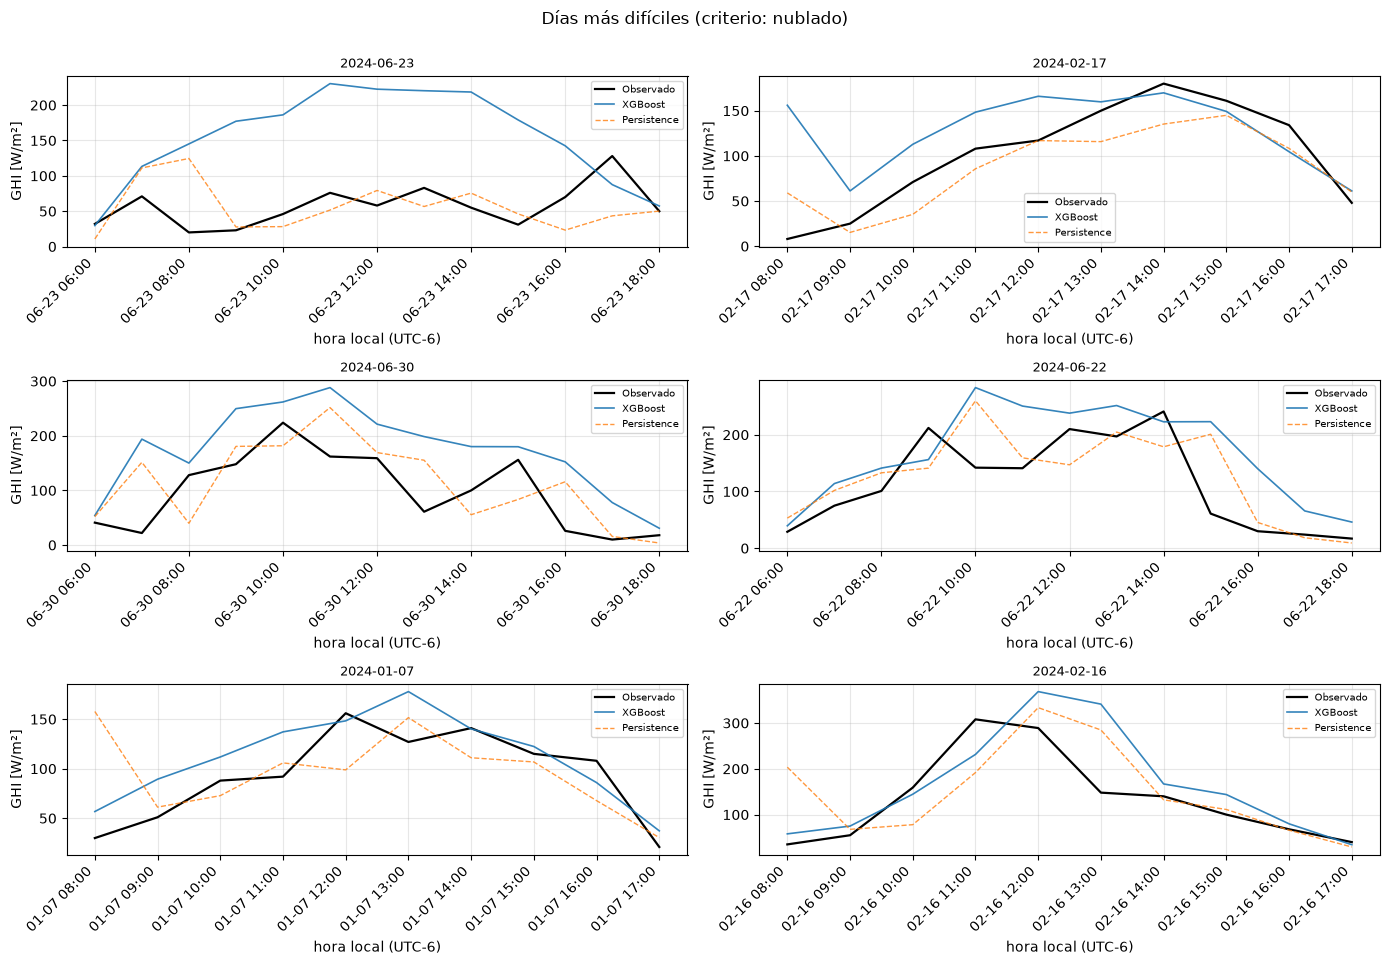

In [9]:
# Series temporales de los 6 días más NUBLADOS (la línea se corta en la noche).
viz.plot_dias_dificiles(n=6, criterio='nublado', variable='ghi')
plt.show()

## Conclusión

El primer XGBoost **supera a smart persistence** (skill > 0 en val y test, R² test
0.926 vs 0.916). Las features dominantes son `kt_lag1`, `kt_last_op` (la persistencia
como feature) y `cloud_type_lag1`. Los días más difíciles son los nublados/variables
y con mucho relleno satelital, donde el error se dispara; aun así el modelo suele
batir a persistence también ahí. Ver `docs/fase3_xgboost.md` y `fase3_xgb_metrics.csv`.
Próximo: hiperparámetros, features de nubes/aerosoles, horizonte t+24 y multi-nodo.